In [19]:
from PIL import Image, ImageDraw
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [20]:
def fwhm(files,folder_path):
    widths = []
    for filename in files:
       csv_path = folder_path + "/"+ filename
       #csv_path = os.path.join(folder_path, filename)
       # Read CSV
       df = pd.read_csv(csv_path)
       y = df["intensity"].to_numpy()
       i = y.argmax()
       h = y[i] / 2
       l = np.where(y[:i] < h)[0][-1]
       r = i+np.where(y[i:] < h)[0][0]
       width =r-l
       widths.append(width)
    return widths

In [21]:
def extract_brightest_pixel(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.lower().endswith(".png"):
            img_path = os.path.join(input_folder, filename)

            # Open image as grayscale
            img = Image.open(img_path).convert("L")
            arr = np.array(img)  # shape = (height, width)
            print(len(arr[0]))
            # Find brightest pixel in whole image
            peak_index = np.argmax(arr)
            peak_y, peak_x = np.unravel_index(peak_index, arr.shape)

            # Read horizontal line through brightest pixel
            row_profile = arr[peak_y, :]

            csv_name = os.path.splitext(filename)[0] + "brightestpixel.csv"
            csv_path = os.path.join(output_folder, csv_name)

            with open(csv_path, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(["intensity"])

                for x, intensity in enumerate(row_profile):
                    writer.writerow([int(intensity)])

            print(f"Saved: {csv_path}   (read row y = {peak_y})")

In [22]:
def subtract_dark(input_folder, dark_path, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    # Load dark frame and convert to float32
    dark = np.array(Image.open(dark_path).convert("L"), dtype=np.float32)

    for filename in sorted(os.listdir(input_folder)):
        if not filename.lower().endswith(".png"):
            continue

        img_path = os.path.join(input_folder, filename)
        img = np.array(Image.open(img_path).convert("L"), dtype=np.float32)

        # Subtract dark and clip to valid range
        corrected = np.clip(img - dark, 0, 255).astype(np.uint8)

        out_path = os.path.join(output_folder, filename)
        Image.fromarray(corrected).save(out_path)
        print(f"Saved: {out_path}")

# Run
dark = "Dark/dark.png"
input_folder = "14330705scan_images"
output_folder = "14330705_cleaned"

subtract_dark(input_folder, dark, output_folder)

Saved: 14330705_cleaned\img_0000_0.0mm.png
Saved: 14330705_cleaned\img_0001_0.5mm.png
Saved: 14330705_cleaned\img_0002_1.0mm.png
Saved: 14330705_cleaned\img_0003_1.5mm.png
Saved: 14330705_cleaned\img_0004_2.0mm.png
Saved: 14330705_cleaned\img_0005_2.5mm.png
Saved: 14330705_cleaned\img_0006_3.0mm.png
Saved: 14330705_cleaned\img_0007_3.5mm.png
Saved: 14330705_cleaned\img_0008_4.0mm.png
Saved: 14330705_cleaned\img_0009_4.5mm.png
Saved: 14330705_cleaned\img_0010_5.0mm.png
Saved: 14330705_cleaned\img_0011_5.5mm.png
Saved: 14330705_cleaned\img_0012_6.0mm.png
Saved: 14330705_cleaned\img_0013_6.5mm.png
Saved: 14330705_cleaned\img_0014_7.0mm.png
Saved: 14330705_cleaned\img_0015_7.5mm.png
Saved: 14330705_cleaned\img_0016_8.0mm.png
Saved: 14330705_cleaned\img_0017_8.5mm.png
Saved: 14330705_cleaned\img_0018_9.0mm.png
Saved: 14330705_cleaned\img_0019_9.5mm.png
Saved: 14330705_cleaned\img_0020_10.0mm.png


In [23]:
extract_brightest_pixel("14330705scan_images","14330705scan_CSV_images")
extract_brightest_pixel("14330705_cleaned", "14330705_cleaned_CSV_images")

1280
Saved: 14330705scan_CSV_images\img_0000_0.0mmbrightestpixel.csv   (read row y = 431)
1280
Saved: 14330705scan_CSV_images\img_0001_0.5mmbrightestpixel.csv   (read row y = 365)
1280
Saved: 14330705scan_CSV_images\img_0002_1.0mmbrightestpixel.csv   (read row y = 361)
1280
Saved: 14330705scan_CSV_images\img_0003_1.5mmbrightestpixel.csv   (read row y = 365)
1280
Saved: 14330705scan_CSV_images\img_0004_2.0mmbrightestpixel.csv   (read row y = 363)
1280
Saved: 14330705scan_CSV_images\img_0005_2.5mmbrightestpixel.csv   (read row y = 368)
1280
Saved: 14330705scan_CSV_images\img_0006_3.0mmbrightestpixel.csv   (read row y = 364)
1280
Saved: 14330705scan_CSV_images\img_0007_3.5mmbrightestpixel.csv   (read row y = 368)
1280
Saved: 14330705scan_CSV_images\img_0008_4.0mmbrightestpixel.csv   (read row y = 366)
1280
Saved: 14330705scan_CSV_images\img_0009_4.5mmbrightestpixel.csv   (read row y = 366)
1280
Saved: 14330705scan_CSV_images\img_0010_5.0mmbrightestpixel.csv   (read row y = 372)
1280
Saved

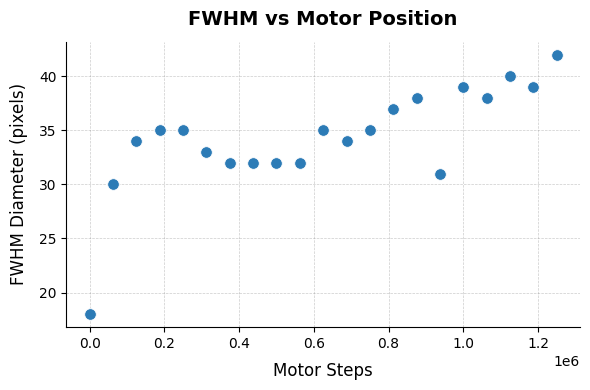

In [24]:
folder_path = "14330705_cleaned_CSV_images"

file_paths = sorted([
    f for f in os.listdir(folder_path)
    if f.endswith(".csv")
])


STEP_MM = 0.5                  # move in 0.5 mm increments
STEPS_PER_MM = int(1e-3/(0.5e-9*8))
steps = STEPS_PER_MM * STEP_MM * np.linspace(0,10,21) # steps taken by motor

pixel = fwhm(file_paths,folder_path) #diameter of fwhm in pixel

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(steps, pixel,
           color="#2C7BB6", edgecolors="white", linewidths=0.6,
           s=70, zorder=3)

# Light grid
ax.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.4)
ax.set_axisbelow(True)

# Labels & title
ax.set_xlabel("Motor Steps", fontsize=12, labelpad=8)
ax.set_ylabel("FWHM Diameter (pixels)", fontsize=12, labelpad=8)
ax.set_title("FWHM vs Motor Position", fontsize=14, fontweight="bold", pad=12)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

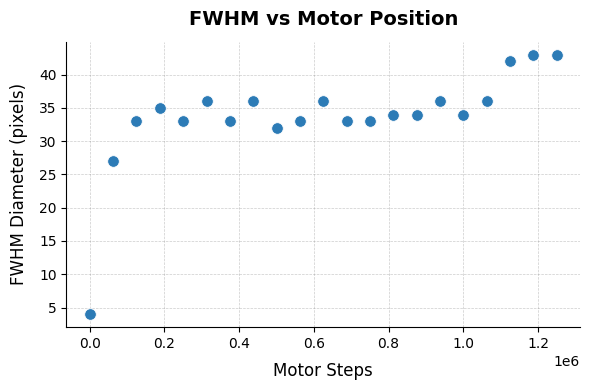

In [25]:
folder_path = "14330705scan_CSV_images"

file_paths = sorted([
    f for f in os.listdir(folder_path)
    if f.endswith(".csv")
])


STEP_MM = 0.5                  # move in 0.5 mm increments
STEPS_PER_MM = int(1e-3/(0.5e-9*8))
steps = STEPS_PER_MM * STEP_MM * np.linspace(0,10,21) # steps taken by motor

pixel = fwhm(file_paths,folder_path) #diameter of fwhm in pixel

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(steps, pixel,
           color="#2C7BB6", edgecolors="white", linewidths=0.6,
           s=70, zorder=3)

# Light grid
ax.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.4)
ax.set_axisbelow(True)

# Labels & title
ax.set_xlabel("Motor Steps", fontsize=12, labelpad=8)
ax.set_ylabel("FWHM Diameter (pixels)", fontsize=12, labelpad=8)
ax.set_title("FWHM vs Motor Position", fontsize=14, fontweight="bold", pad=12)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

In [38]:
def sum_around_brightest(path, radius=40):
    img = np.array(Image.open(path).convert("L"), dtype=np.float32)

    # Sum of 5 consecutive pixels in each row → find the peak window center
    kernel = np.ones((5, 5))
    from scipy.ndimage import convolve
    smoothed = convolve(img, kernel, mode='reflect')
    row, col = np.unravel_index(np.argmax(smoothed), img.shape)

    r0, r1 = max(row - radius, 0), min(row + radius + 1, img.shape[0])
    c0, c1 = max(col - radius, 0), min(col + radius + 1, img.shape[1])

    return img[r0:r1, c0:c1].sum(), (row, col)

In [39]:
signal, pos = sum_around_brightest("14330705scan_images/img_0000_0.0mm.png")
print(f"total signal around {pos}: {signal}")

total signal around (np.int64(368), np.int64(960)): 230016.0


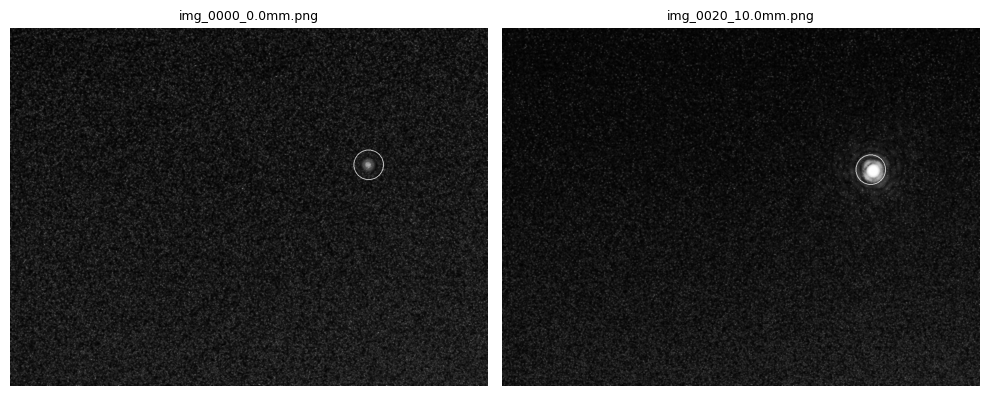

In [40]:
def preview_first_last(folder, radius=40):
    paths = sorted([
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(".png")
    ])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for ax, path in zip(axes, [paths[0], paths[-1]]):
        img = Image.open(path).convert("L")
        draw = ImageDraw.Draw(img)
        _, (row, col) = sum_around_brightest(path, radius)
        draw.ellipse([col - radius, row - radius, col + radius, row + radius],
                     outline=255, width=2)
        ax.imshow(img, cmap="gray")
        ax.set_title(os.path.basename(path), fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# --- Usage ---
preview_first_last("14330705scan_images")

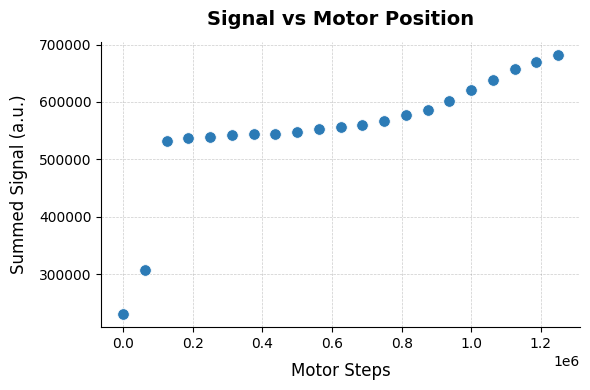

In [42]:
folder_path = "14330705scan_images"
file_paths = sorted([
    os.path.join(folder_path, f)
    for f in os.listdir(folder_path)
    if f.lower().endswith(".png")
])

signal = [sum_around_brightest(p)[0] for p in file_paths]

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(steps, signal,
           color="#2C7BB6", edgecolors="white", linewidths=0.6,
           s=70, zorder=3)

ax.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.4)
ax.set_axisbelow(True)

ax.set_xlabel("Motor Steps", fontsize=12, labelpad=8)
ax.set_ylabel("Summed Signal (a.u.)", fontsize=12, labelpad=8)
ax.set_title("Signal vs Motor Position", fontsize=14, fontweight="bold", pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()